In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df=pd.read_csv("/kaggle/input/datasets/ruthgn/wine-quality-data-set-red-white-wine/wine-quality-white-and-red.csv",header=None,usecols=[0,1,4])

In [32]:
df.columns=['Id','Malic Acid','Alcohol']

In [34]:
df = df.iloc[1:].reset_index(drop=True)

In [35]:
df.head()

,Id,Malic Acid,Alcohol
0,white,7,20.7
1,white,6.3,1.6
2,white,8.1,6.9
3,white,7.2,8.5
4,white,7.2,8.5


<Axes: xlabel='Alcohol', ylabel='Density'>

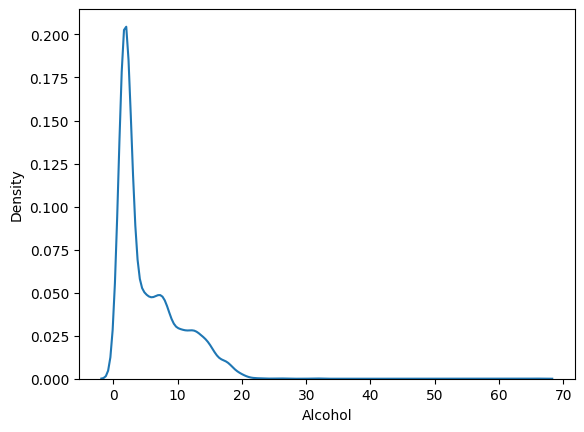

In [36]:
df['Alcohol'] = pd.to_numeric(df['Alcohol'], errors='coerce')
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

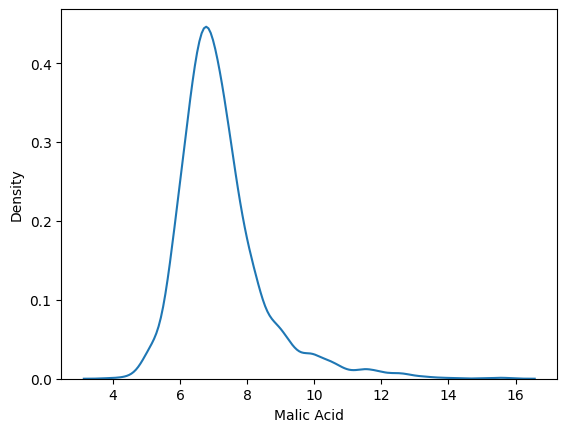

In [37]:
df['Malic Acid'] = pd.to_numeric(df['Malic Acid'], errors='coerce')
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Malic Acid', ylabel='Alcohol'>

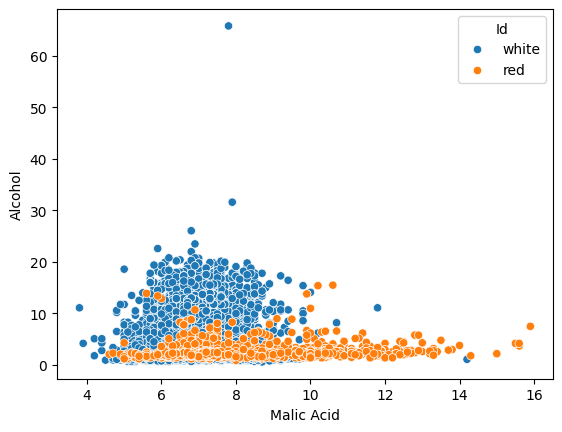

In [38]:
sns.scatterplot(x=df['Malic Acid'],y=df['Alcohol'],hue=df['Id'])

In [39]:
from sklearn.model_selection import train_test_split

In [43]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('Id',axis=1),
                                               df['Id'],
                                               test_size=0.3,
                                               random_state=42)

In [44]:
X_train.shape

(4547, 2)

In [45]:
X_test.shape


(1950, 2)

In [47]:
from sklearn.preprocessing import MinMaxScaler

In [48]:
scaler=MinMaxScaler()

In [50]:
scaler.fit(X_train)

MinMaxScaler()

In [52]:
X_train_sc=scaler.transform(X_train)
X_test_sc=scaler.transform(X_test)


In [56]:
X_train_sc=pd.DataFrame(X_train_sc,columns=X_train.columns)
X_test_sc=pd.DataFrame(X_test_sc,columns=X_test.columns)

In [57]:
X_train.describe()

,Malic Acid,Alcohol
count,4547.00000,4547.000000
mean,7.22119,5.422828
std,1.30368,4.719118
min,3.80000,0.600000
25%,6.40000,1.800000
50%,7.00000,3.000000
75%,7.70000,8.000000
max,15.90000,31.600000


In [58]:
X_train_sc.describe()

,Malic Acid,Alcohol
count,4547.000000,4547.000000
mean,0.282743,0.155575
std,0.107742,0.152230
min,0.000000,0.000000
25%,0.214876,0.038710
50%,0.264463,0.077419
75%,0.322314,0.238710
max,1.000000,1.000000


Text(0.5, 1.0, 'After Scalling')

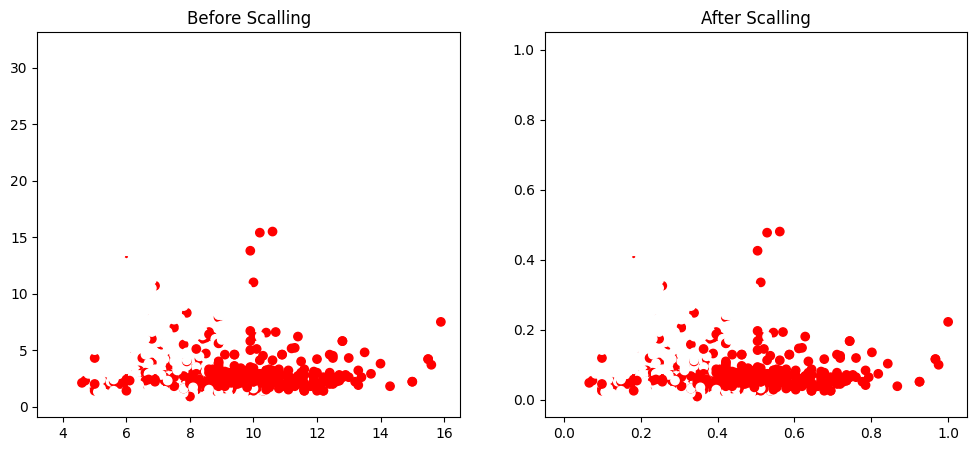

In [66]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Malic Acid'],X_train['Alcohol'],c=y_train)
ax1.set_title('Before Scalling')
ax2.scatter(X_train_sc['Malic Acid'],X_train_sc['Alcohol'],c=y_train)
ax2.set_title('After Scalling')